In [1]:
# ── Uninstall conflicting packages first ──────────────────────────────────────
!pip uninstall -y transformers accelerate peft datasets

# ── Install pinned compatible versions ────────────────────────────────────────
# Root cause: peft needs accelerate>=0.34 for 'clear_device_cache'
# but older accelerate 0.29.x doesn't have it.
!pip install -q \
    transformers==4.44.0 \
    accelerate==0.34.0 \
    peft==0.12.0 \
    datasets==2.19.0 \
    evaluate \
    scikit-learn \
    matplotlib \
    seaborn \
    pandas \
    numpy \
    tqdm

# ── CRITICAL: restart runtime after install ───────────────────────────────────
print('✅ Packages installed.')
print('⚠️  NOW GO TO:  Runtime → Restart session  then re-run from Cell 2 onwards.')

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0

In [2]:
import os, json, math, warnings, time, copy, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer, AutoModelForMaskedLM, AutoConfig,
    DataCollatorForLanguageModeling,
    TrainingArguments, Trainer, TrainerCallback, set_seed,
)
from datasets import Dataset

warnings.filterwarnings('ignore')
set_seed(42)
print('✅ Imports OK')

✅ Imports OK


In [3]:
from pathlib import Path
BASE_ROOT = Path('/content/drive/MyDrive/Rajdeep_Document')

PATHS = dict(
    csv         = BASE_ROOT / 'data'    / 'climate_dataset_cleaned.csv',
    model_dir   = BASE_ROOT / 'models'  / 'final' / 'dapt_minilm_climate',
    grid_dir    = BASE_ROOT / 'models'  / 'grid_search',
    log_dir     = BASE_ROOT / 'logs'    / 'final',
    log_csv     = BASE_ROOT / 'logs'    / 'final' / 'dapt_training_logs.csv',
    grid_log    = BASE_ROOT / 'logs'    / 'final' / 'grid_search_logs.csv',
    results_dir = BASE_ROOT / 'results',
    eval_json   = BASE_ROOT / 'results' / 'dapt_evaluation_results.json',
    report_txt  = BASE_ROOT / 'results' / 'dapt_comparison_report.txt',
    plots_dir   = BASE_ROOT / 'plots',
)

for p in [PATHS['model_dir'], PATHS['grid_dir'], PATHS['log_dir'],
          PATHS['results_dir'], PATHS['plots_dir']]:
    Path(p).mkdir(parents=True, exist_ok=True)

PATHS = {k: str(v) for k, v in PATHS.items()}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

🖥️  Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


In [4]:
# ── Grid Search space ───────────────────────
GRID_LR         = [1e-5, 3e-5, 5e-5]
GRID_BATCH      = [8, 16, 32]

CFG = dict(
    base_model      = 'microsoft/MiniLM-L12-H384-uncased',
    text_column     = None,

    # ── Phase 1: short sequence, grid search ──────────────────────
    seq_len_phase1  = 128,          # start at 128
    mlm_probability = 0.15,         # standard MLM mask rate
    grid_epochs     = 10,           # fewer epochs for DAPT
    warmup_ratio    = 0.1,
    weight_decay    = 0.01,
    val_split       = 0.1,
    dropout         = 0.2,

    # ── Phase 2: long sequence, best combo only ───────────────────
    seq_len_phase2  = 512,          # optionally extend to 512
    phase2_epochs   = 5,
    phase2_lr_scale = 0.5,          # halve lr for phase 2 fine-tuning

    seed            = 42,
    **PATHS,
)

print('Config ready.')
print(f'   Grid LR values     : {GRID_LR}')
print(f'   Grid Batch values  : {GRID_BATCH}')
print(f'   Total combinations : {len(GRID_LR)*len(GRID_BATCH)}')
print(f'   Phase 1 seq_len    : {CFG["seq_len_phase1"]} tokens')
print(f'   Phase 2 seq_len    : {CFG["seq_len_phase2"]} tokens')
print(f'   Epochs per combo   : {CFG["grid_epochs"]}')

Config ready.
   Grid LR values     : [1e-05, 3e-05, 5e-05]
   Grid Batch values  : [8, 16, 32]
   Total combinations : 9
   Phase 1 seq_len    : 128 tokens
   Phase 2 seq_len    : 512 tokens
   Epochs per combo   : 10


In [5]:
DRIVE_ROOT = '/content/drive/MyDrive/Rajdeep_Document'
PATHS['csv'] = f'{DRIVE_ROOT}/data/climate_dataset_cleaned.csv'
CFG.update(PATHS)

df = pd.read_csv(PATHS['csv'])
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print(f'Nulls   :\n{df.isnull().sum()}')

# Auto-detect text column
CANDIDATES = ['text','content','body','sentence','abstract',
              'description','article','passage','paragraph']
detected = None
for c in df.columns:
    if c.lower() in CANDIDATES:
        detected = c; break
if detected is None:
    str_cols = df.select_dtypes(include='object').columns
    detected = df[str_cols].applymap(lambda x: len(str(x))).mean().idxmax()

CFG['text_column'] = detected
print(f'\nText column: "{detected}"')

df = df[[detected]].dropna()
df[detected] = df[detected].astype(str).str.strip()
df = df[df[detected].str.len() > 20].reset_index(drop=True)
print(f'Rows after clean: {len(df):,}')

Shape   : (17346, 6)
Columns : ['text_clean', 'source_file', 'folder', 'lang', 'word_count', 'climate_score']
Nulls   :
text_clean       0
source_file      0
folder           0
lang             0
word_count       0
climate_score    0
dtype: int64

Text column: "text_clean"
Rows after clean: 17,332


In [7]:
# ── Load tokenizer ────────────────────────────────────────────────
TEXT_COL  = CFG['text_column']
tokenizer = AutoTokenizer.from_pretrained(CFG['base_model'])

# ── Phase 1 tokenization @ seq_len = 128 ─────────────────────────
def tokenize_fn_128(examples):
    return tokenizer(
        examples[TEXT_COL],
        truncation=True,
        max_length=CFG['seq_len_phase1'],   # 128 tokens
        padding=False,
        return_special_tokens_mask=True,
    )

hf_ds        = Dataset.from_pandas(df)
tokenized_128 = hf_ds.map(
    tokenize_fn_128, batched=True,
    remove_columns=[TEXT_COL], desc='Tokenising @128'
)
split_128    = tokenized_128.train_test_split(test_size=CFG['val_split'], seed=CFG['seed'])
train_ds_128 = split_128['train']
eval_ds_128  = split_128['test']

# ── DYNAMIC MASKING COLLATOR ──────────────────────────────────────
# DataCollatorForLanguageModeling generates a NEW random mask every
# epoch → model never sees the same mask twice → better generalisation
# This is "dynamic masking" as recommended for continued pre-training.
collator_128 = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True,
    mlm_probability=CFG['mlm_probability'],
)

print(f' Phase 1 dataset ready')
print(f'   Train : {len(train_ds_128):,} samples  (seq_len={CFG["seq_len_phase1"]})')
print(f'   Eval  : {len(eval_ds_128):,} samples')
print(f'   MLM   : dynamic masking (mask_prob={CFG["mlm_probability"]})')

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenising @128:   0%|          | 0/17332 [00:00<?, ? examples/s]

 Phase 1 dataset ready
   Train : 15,598 samples  (seq_len=128)
   Eval  : 1,734 samples
   MLM   : dynamic masking (mask_prob=0.15)


### Text Length Analysis

Avg character length  : 212 chars
Max / Min char length : 3632 / 21 chars
Avg word count        : 38 words
Max / Min word count  : 512 / 5 words


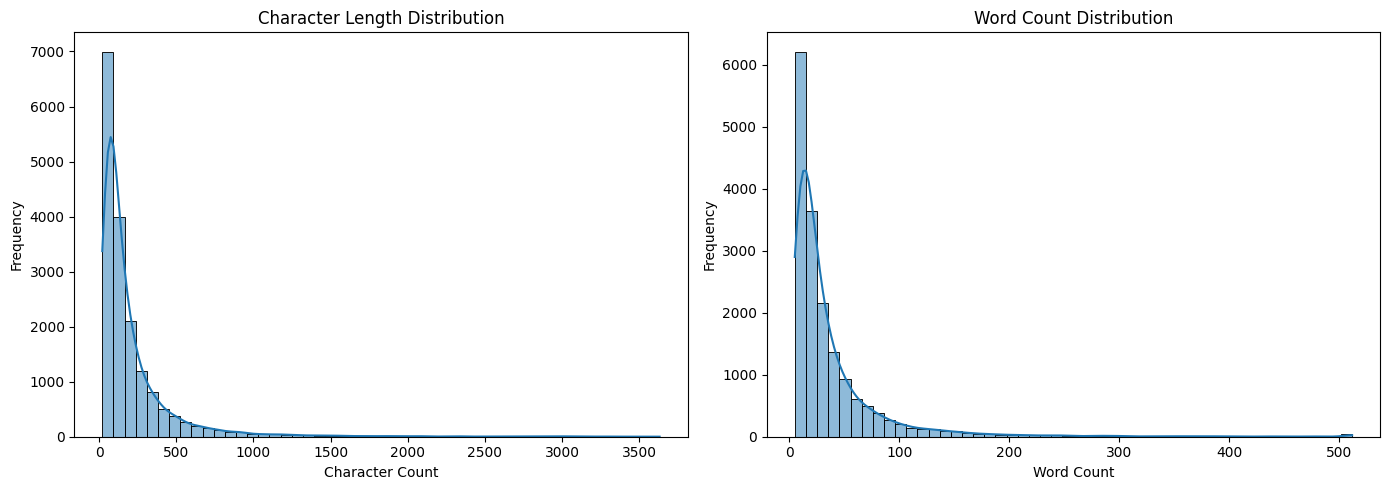


 Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_dataset_distribution.png


In [8]:
df['char_length'] = df[TEXT_COL].apply(len)
df['word_count'] = df[TEXT_COL].apply(lambda x: len(str(x).split()))

print(f"Avg character length  : {df['char_length'].mean():.0f} chars")
print(f"Max / Min char length : {df['char_length'].max()} / {df['char_length'].min()} chars")
print(f"Avg word count        : {df['word_count'].mean():.0f} words")
print(f"Max / Min word count  : {df['word_count'].max()} / {df['word_count'].min()} words")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['char_length'], bins=50, kde=True)
plt.title('Character Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(f"{PATHS['plots_dir']}/dapt_dataset_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Saved → {PATHS['plots_dir']}/dapt_dataset_distribution.png")

In [9]:
total_words_dataset = df['word_count'].sum()
print(f'Total number of words in the entire dataset: {total_words_dataset:,}')

Total number of words in the entire dataset: 657,209


In [10]:
def compute_perplexity(model, dataset, collator, batch_size=64, desc='Eval'):
    loader = DataLoader(
        dataset, batch_size=batch_size,
        collate_fn=collator, pin_memory=torch.cuda.is_available()
    )
    total_loss, n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            total_loss += model(**batch).loss.item()
            n += 1
    avg = total_loss / n
    return {'loss': round(avg, 4), 'perplexity': round(math.exp(avg), 4)}

print('📏 Computing BASELINE metrics...')
baseline_model = AutoModelForMaskedLM.from_pretrained(CFG['base_model']).to(DEVICE)
baseline_model.eval()
BEFORE_METRICS = compute_perplexity(
    baseline_model, eval_ds_128, collator_128, batch_size=64, desc='Baseline'
)
print(f'\n   BEFORE — Loss      : {BEFORE_METRICS["loss"]}')
print(f'   BEFORE — Perplexity: {BEFORE_METRICS["perplexity"]}')

del baseline_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('\n🧹 Baseline model freed.')

📏 Computing BASELINE metrics...


pytorch_model.bin:   0%|          | 0.00/133M [00:00<?, ?B/s]

Some weights of BertForMaskedLM were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Baseline:   0%|          | 0/28 [00:00<?, ?it/s]


   BEFORE — Loss      : 10.9017
   BEFORE — Perplexity: 54266.4045

🧹 Baseline model freed.


In [11]:
class DetailedLoggerCallback(TrainerCallback):
    def __init__(self):
        self.records      = []
        self._step_losses = []
        self._epoch_start = None

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._epoch_start = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self._step_losses.append(logs['loss'])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        eval_loss  = metrics.get('eval_loss', float('nan'))
        ppl        = math.exp(eval_loss) if not math.isnan(eval_loss) else float('nan')
        train_loss = (sum(self._step_losses)/len(self._step_losses)
                      if self._step_losses else float('nan'))
        lr         = (state.log_history[-1].get('learning_rate', float('nan'))
                      if state.log_history else float('nan'))
        rec = dict(
            epoch        = int(round(state.epoch)),
            train_loss   = round(train_loss, 6),
            eval_loss    = round(eval_loss,  6),
            perplexity   = round(ppl,        4),
            learning_rate= lr,
            epoch_time_s = round(time.time()-self._epoch_start, 2)
                           if self._epoch_start else None,
        )
        self.records.append(rec)
        self._step_losses = []
        print(f"  Ep {rec['epoch']:>2} | "
              f"Train {rec['train_loss']:.4f} | "
              f"Eval {rec['eval_loss']:.4f} | "
              f"PPL {rec['perplexity']:.3f} | "
              f"LR {rec['learning_rate']:.2e}")

print('✅ Callback ready.')

✅ Callback ready.


In [ ]:
#  GRID SEARCH  —  lr × batch_size  (9 combinations × 10 epochs)

GRID_RESULTS   = {}          
BEST_COMBO_KEY = None
BEST_COMBO_PPL = float('inf')
BEST_COMBO_CFG = {}

total_combos = len(GRID_LR) * len(GRID_BATCH)
combo_num    = 0

print(f'Starting Grid Search: {total_combos} combinations\n')
print(f'  LR values   : {GRID_LR}')
print(f'  Batch values: {GRID_BATCH}')
print(f'  Epochs each : {CFG["grid_epochs"]}')
print(f'  Seq length  : {CFG["seq_len_phase1"]} (Phase 1)\n')
grid_start = time.time()

for lr, batch_size in itertools.product(GRID_LR, GRID_BATCH):
    combo_num  += 1
    combo_key   = f'lr={lr:.0e}_bs={batch_size}'

    print(f'\n{"="*65}')
    print(f'  Combo {combo_num}/{total_combos}: {combo_key}')
    print(f'{"="*65}')

    # Fresh model with dropout=0.2 for each combo
    dapt_cfg = AutoConfig.from_pretrained(CFG['base_model'])
    dapt_cfg.hidden_dropout_prob          = CFG['dropout']
    dapt_cfg.attention_probs_dropout_prob = CFG['dropout']
    model = AutoModelForMaskedLM.from_pretrained(CFG['base_model'], config=dapt_cfg)

    logger          = DetailedLoggerCallback()
    steps_per_epoch = math.ceil(len(train_ds_128) / batch_size)
    total_steps     = steps_per_epoch * CFG['grid_epochs']
    warmup_steps    = int(total_steps * CFG['warmup_ratio'])
    combo_out_dir   = f"{PATHS['grid_dir']}/{combo_key}"

    args = TrainingArguments(
        output_dir                  = combo_out_dir,
        num_train_epochs            = CFG['grid_epochs'],
        per_device_train_batch_size = batch_size,
        per_device_eval_batch_size  = 64,
        learning_rate               = lr,
        weight_decay                = CFG['weight_decay'],
        warmup_steps                = warmup_steps,
        lr_scheduler_type           = 'cosine',
        fp16                        = False,
        eval_strategy               = 'epoch',
        save_strategy               = 'no',         # no disk save during grid
        logging_steps               = max(10, steps_per_epoch // 4),
        report_to                   = 'none',
        seed                        = CFG['seed'],
        dataloader_num_workers      = 2,
        push_to_hub                 = False,
    )

    trainer = Trainer(
        model         = model,
        args          = args,
        train_dataset = train_ds_128,
        eval_dataset  = eval_ds_128,
        tokenizer     = tokenizer,
        data_collator = collator_128,
        callbacks     = [logger],
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    log_df       = pd.DataFrame(logger.records)
    final_ppl    = log_df['perplexity'].iloc[-1]
    best_ppl     = log_df['perplexity'].min()
    final_loss   = log_df['eval_loss'].iloc[-1]

    GRID_RESULTS[combo_key] = {
        'lr'              : lr,
        'batch_size'      : batch_size,
        'log_df'          : log_df,
        'best_eval_loss'  : log_df['eval_loss'].min(),
        'best_perplexity' : best_ppl,
        'final_eval_loss' : final_loss,
        'final_perplexity': final_ppl,
        'train_time_min'  : round(elapsed / 60, 2),
    }

    # Save logs to CSV
    Path(PATHS['log_dir']).mkdir(parents=True, exist_ok=True)
    log_df['combo'] = combo_key
    log_df.to_csv(f"{PATHS['log_dir']}/grid_{combo_key}.csv", index=False)

    # Track best model
    if final_ppl < BEST_COMBO_PPL:
        BEST_COMBO_PPL = final_ppl
        BEST_COMBO_KEY = combo_key
        BEST_COMBO_CFG = {'lr': lr, 'batch_size': batch_size}
        # Save best model so far to disk
        best_ckpt_dir = f"{PATHS['grid_dir']}/best_so_far"
        model.save_pretrained(best_ckpt_dir)
        tokenizer.save_pretrained(best_ckpt_dir)
        print(f'  New best! PPL={final_ppl:.4f} saved to {best_ckpt_dir}')

    print(f'\n  Done in {elapsed/60:.1f} min | '
          f'Final PPL={final_ppl:.4f} | Best PPL={best_ppl:.4f}')

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

total_grid_time = (time.time() - grid_start) / 60
print(f'\n{"="*65}')
print(f'  Grid Search Complete in {total_grid_time:.1f} min')
print(f'  Best combo : {BEST_COMBO_KEY}')
print(f'  Best PPL   : {BEST_COMBO_PPL:.4f}')
print(f'{"="*65}')

# Combined log CSV
all_logs = pd.concat(
    [r['log_df'].assign(combo=k, lr=r['lr'], batch_size=r['batch_size'])
     for k, r in GRID_RESULTS.items()],
    ignore_index=True
)
all_logs.to_csv(PATHS['grid_log'], index=False)
print(f'\n  All logs saved → {PATHS["grid_log"]}')

Starting Grid Search: 9 combinations

  LR values   : [1e-05, 3e-05, 5e-05]
  Batch values: [8, 16, 32]
  Epochs each : 10
  Seq length  : 128 (Phase 1)


  Combo 1/9: lr=1e-05_bs=8


Some weights of BertForMaskedLM were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,6.015600,5.608512
2,5.089500,4.834169
3,4.774300,4.538369
4,4.574300,4.303248
5,4.422900,4.246756
6,4.349900,4.146728
7,4.293900,4.080070
8,4.292500,4.078640
9,4.229600,4.047370
10,4.257900,4.092133


  Ep  1 | Train 7.2875 | Eval 5.6085 | PPL 272.738 | LR nan
  Ep  2 | Train 5.3482 | Eval 4.8342 | PPL 125.734 | LR nan
  Ep  3 | Train 4.8700 | Eval 4.5384 | PPL 93.538 | LR nan
  Ep  4 | Train 4.6120 | Eval 4.3032 | PPL 73.940 | LR nan
  Ep  5 | Train 4.4746 | Eval 4.2468 | PPL 69.878 | LR nan
  Ep  6 | Train 4.3832 | Eval 4.1467 | PPL 63.227 | LR nan
  Ep  7 | Train 4.3043 | Eval 4.0801 | PPL 59.150 | LR nan
  Ep  8 | Train 4.2709 | Eval 4.0786 | PPL 59.065 | LR nan
  Ep  9 | Train 4.2424 | Eval 4.0474 | PPL 57.247 | LR nan
  Ep 10 | Train 4.2447 | Eval 4.0921 | PPL 59.867 | LR nan
  New best! PPL=59.8675 saved to /content/drive/MyDrive/Rajdeep_Document/models/grid_search/best_so_far

  Done in 27.6 min | Final PPL=59.8675 | Best PPL=57.2467

  Combo 2/9: lr=1e-05_bs=16


Some weights of BertForMaskedLM were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForMaskedLM were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,5.367500,5.029579
2,4.618100,4.352756
3,4.339700,4.098822
4,4.115200,3.852486
5,3.961400,3.793017
6,3.866000,3.694200
7,3.797400,3.602626
8,3.738300,3.588566
9,3.745500,3.561746


  Ep  1 | Train 6.5926 | Eval 5.0296 | PPL 152.869 | LR nan
  Ep  2 | Train 4.8189 | Eval 4.3528 | PPL 77.692 | LR nan
  Ep  3 | Train 4.4014 | Eval 4.0988 | PPL 60.269 | LR nan
  Ep  4 | Train 4.1719 | Eval 3.8525 | PPL 47.110 | LR nan
  Ep  5 | Train 4.0125 | Eval 3.7930 | PPL 44.390 | LR nan
  Ep  6 | Train 3.9044 | Eval 3.6942 | PPL 40.213 | LR nan
  Ep  7 | Train 3.8179 | Eval 3.6026 | PPL 36.694 | LR nan
  Ep  8 | Train 3.7880 | Eval 3.5886 | PPL 36.182 | LR nan
  Ep  9 | Train 3.7404 | Eval 3.5617 | PPL 35.225 | LR nan


Epoch,Training Loss,Validation Loss
1,5.367500,5.029579
2,4.618100,4.352756
3,4.339700,4.098822
4,4.115200,3.852486
5,3.961400,3.793017
6,3.866000,3.694200
7,3.797400,3.602626
8,3.738300,3.588566
9,3.745500,3.561746
10,3.745700,3.609658


  Ep 10 | Train 3.7322 | Eval 3.6097 | PPL 36.953 | LR nan

  Done in 24.7 min | Final PPL=36.9534 | Best PPL=35.2246

  Grid Search Complete in 234.9 min
  Best combo : lr=5e-05_bs=8
  Best PPL   : 28.9306

  All logs saved → /content/drive/MyDrive/Rajdeep_Document/logs/final/grid_search_logs.csv


In [ ]:
# ── Summary table ─────────────────────────────────────────────────
summary_rows = []
for k, v in GRID_RESULTS.items():
    summary_rows.append({
        'combo'           : k,
        'lr'              : v['lr'],
        'batch_size'      : v['batch_size'],
        'best_perplexity' : round(v['best_perplexity'],  4),
        'final_perplexity': round(v['final_perplexity'], 4),
        'best_eval_loss'  : round(v['best_eval_loss'],   6),
        'final_eval_loss' : round(v['final_eval_loss'],  6),
        'train_time_min'  : v['train_time_min'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('final_perplexity').reset_index(drop=True)
summary_df['rank'] = summary_df.index + 1

print('\n📊 GRID SEARCH RESULTS — Ranked by Final Perplexity')
print('='*75)
print(summary_df.to_string(index=False))
print('='*75)
print(f'\n🏆 BEST  : {BEST_COMBO_KEY}  →  PPL={BEST_COMBO_PPL:.4f}')
print(f'   lr={BEST_COMBO_CFG["lr"]:.0e}  |  batch_size={BEST_COMBO_CFG["batch_size"]}')

# Save summary
summary_df.to_csv(f"{PATHS['results_dir']}/grid_search_summary.csv", index=False)
print(f'\n✅ Summary saved → {PATHS["results_dir"]}/grid_search_summary.csv')

  Loading: microsoft/MiniLM-L12-H384-uncased


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/133M [00:00<?, ?B/s]

Some weights of BertForMaskedLM were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Total parameters : 33,391,290


Tokenising:   0%|          | 0/17332 [00:00<?, ? examples/s]


 Train: 15,598 | Eval: 1,734
 MLM collator ready (mask_prob=0.15)


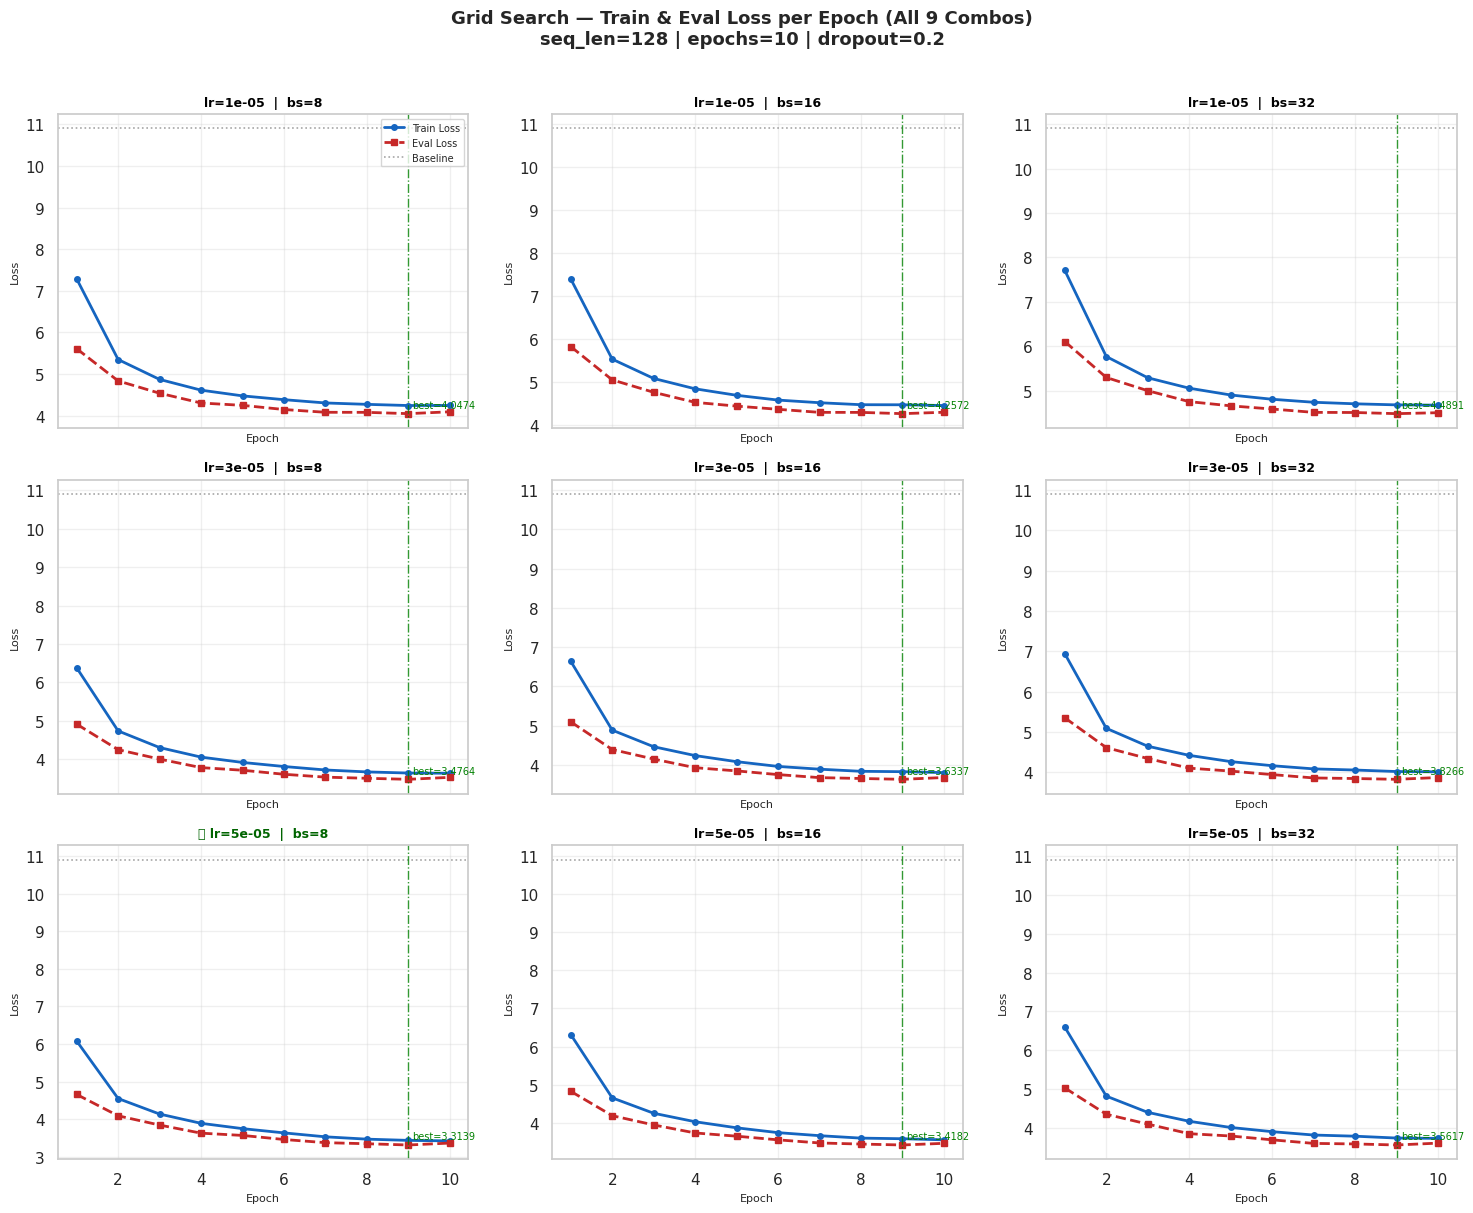

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/grid_loss_panel.png


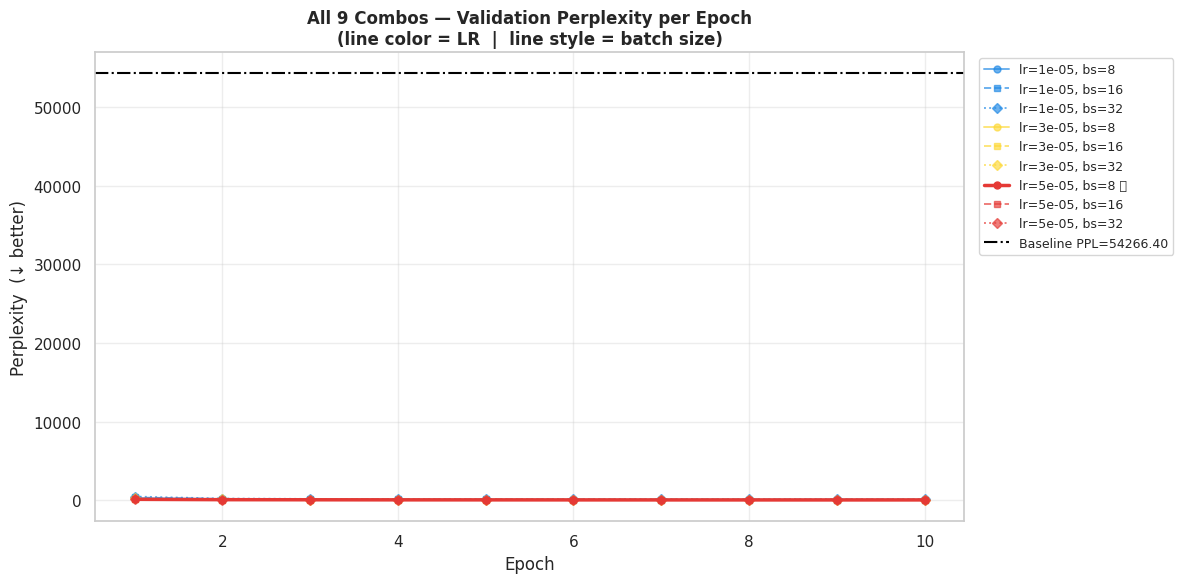

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/grid_all_perplexity.png


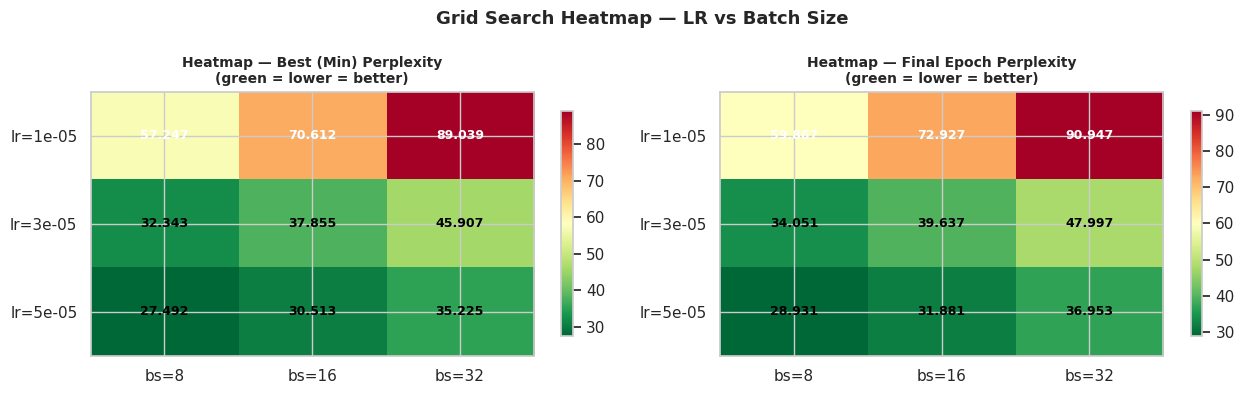

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/grid_heatmap.png


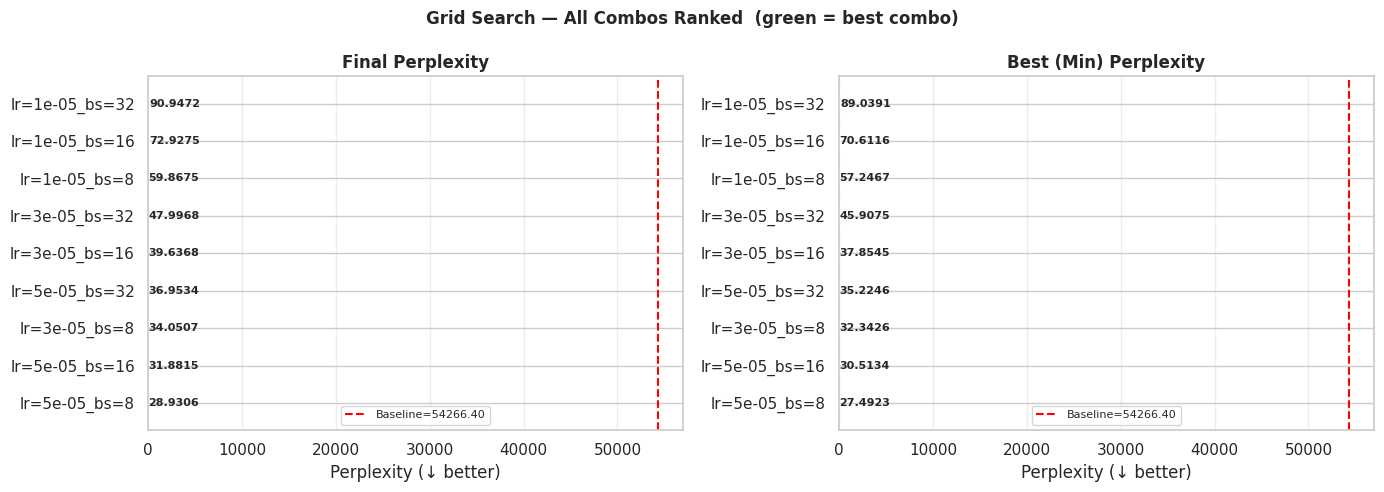

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/grid_ranked_bar.png


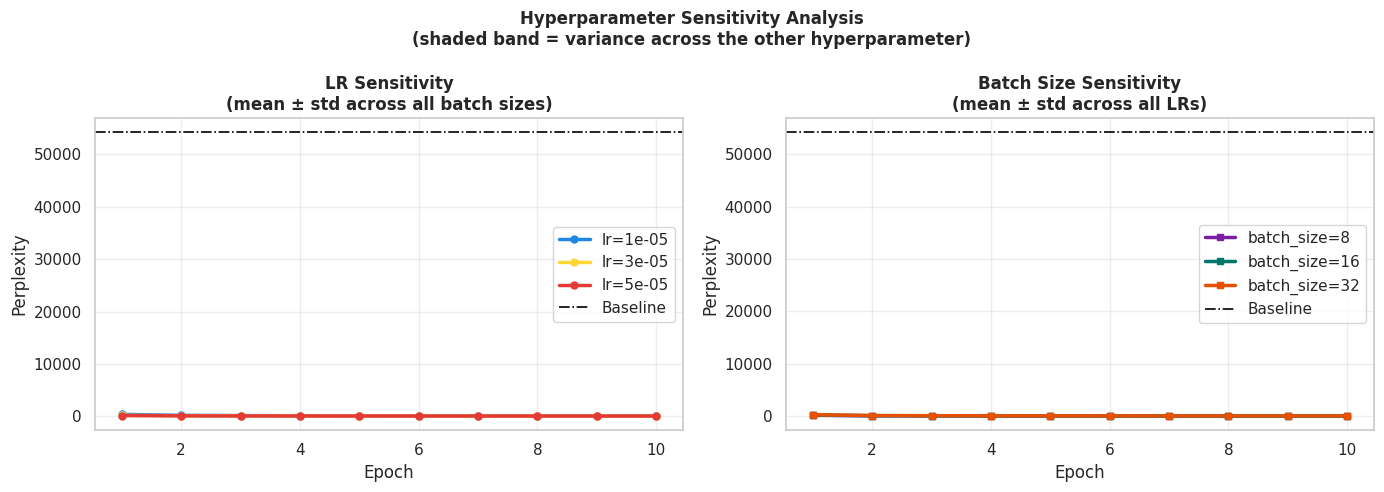

aved → /content/drive/MyDrive/Rajdeep_Document/plots/grid_sensitivity.png


In [ ]:
#  GRID SEARCH VISUALISATION — 5 plot panels
sns.set_theme(style='whitegrid', font_scale=1.0)

LR_COLORS  = {1e-5: '#1E88E5', 3e-5: '#FDD835', 5e-5: '#E53935'}
BS_STYLES  = {8: '-', 16: '--', 32: ':'}
BS_MARKERS = {8: 'o',  16: 's',  32: 'D'}
epochs_arr = np.arange(1, CFG['grid_epochs'] + 1)

# PLOT A — 3×3 panel: train + eval loss per epoch for every combo
fig, axes = plt.subplots(len(GRID_LR), len(GRID_BATCH),
                          figsize=(5*len(GRID_BATCH), 4*len(GRID_LR)),
                          sharex=True)

for ri, lr in enumerate(GRID_LR):
    for ci, bs in enumerate(GRID_BATCH):
        key = f'lr={lr:.0e}_bs={bs}'
        ax  = axes[ri][ci]
        ldf = GRID_RESULTS[key]['log_df']

        ax.plot(ldf['epoch'], ldf['train_loss'], lw=2,
                color='#1565C0', marker='o', ms=4, label='Train Loss')
        ax.plot(ldf['epoch'], ldf['eval_loss'],  lw=2, ls='--',
                color='#C62828', marker='s', ms=4, label='Eval Loss')
        ax.axhline(BEFORE_METRICS['loss'], color='gray', ls=':', lw=1.2,
                   alpha=0.7, label='Baseline')

        best_ep  = ldf['eval_loss'].idxmin()
        best_val = ldf['eval_loss'].min()
        ax.axvline(ldf['epoch'].iloc[best_ep], color='green',
                   ls='-.', lw=1, alpha=0.8)
        ax.annotate(f'best={best_val:.4f}',
                    xy=(ldf['epoch'].iloc[best_ep], best_val),
                    xytext=(3, 4), textcoords='offset points', fontsize=7,
                    color='green')

        is_best = (key == BEST_COMBO_KEY)
        title   = f'lr={lr:.0e}  |  bs={bs}'
        title   = ('⭐ ' if is_best else '') + title
        ax.set_title(title, fontsize=9,
                     fontweight='bold', color='darkgreen' if is_best else 'black')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel('Loss',  fontsize=8)
        ax.grid(alpha=0.3)
        if ri == 0 and ci == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle(
    f'Grid Search — Train & Eval Loss per Epoch (All {len(GRID_RESULTS)} Combos)\n'
    f'seq_len={CFG["seq_len_phase1"]} | epochs={CFG["grid_epochs"]} | dropout=0.2',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/grid_loss_panel.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# PLOT B — All 9 perplexity curves on one chart
fig, ax = plt.subplots(figsize=(12, 6))

for key, res in GRID_RESULTS.items():
    ldf  = res['log_df']
    lr   = res['lr']
    bs   = res['batch_size']
    lw   = 2.5 if key == BEST_COMBO_KEY else 1.4
    alph = 1.0 if key == BEST_COMBO_KEY else 0.65
    ax.plot(
        ldf['epoch'], ldf['perplexity'],
        color=LR_COLORS[lr], ls=BS_STYLES[bs],
        marker=BS_MARKERS[bs], ms=5, lw=lw, alpha=alph,
        label=f'lr={lr:.0e}, bs={bs}' + (' ⭐' if key == BEST_COMBO_KEY else ''),
        zorder=3 if key == BEST_COMBO_KEY else 2
    )

ax.axhline(BEFORE_METRICS['perplexity'], color='black', ls='-.', lw=1.5,
           label=f'Baseline PPL={BEFORE_METRICS["perplexity"]:.2f}')
ax.set_title('All 9 Combos — Validation Perplexity per Epoch\n'
             '(line color = LR  |  line style = batch size)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity  (↓ better)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.35)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/grid_all_perplexity.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# PLOT C — Heatmap: lr vs batch_size → final perplexity
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric_key, title in [
    (axes[0], 'best_perplexity',  'Best (Min) Perplexity'),
    (axes[1], 'final_perplexity', 'Final Epoch Perplexity'),
]:
    heat = np.zeros((len(GRID_LR), len(GRID_BATCH)))
    for ri, lr in enumerate(GRID_LR):
        for ci, bs in enumerate(GRID_BATCH):
            heat[ri, ci] = GRID_RESULTS[f'lr={lr:.0e}_bs={bs}'][metric_key]

    im = ax.imshow(heat, cmap='RdYlGn_r', aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)

    ax.set_xticks(range(len(GRID_BATCH)));  ax.set_xticklabels([f'bs={b}' for b in GRID_BATCH])
    ax.set_yticks(range(len(GRID_LR)));     ax.set_yticklabels([f'lr={l:.0e}' for l in GRID_LR])
    ax.set_title(f'Heatmap — {title}\n(green = lower = better)',
                 fontweight='bold', fontsize=10)

    for ri in range(len(GRID_LR)):
        for ci in range(len(GRID_BATCH)):
            val = heat[ri, ci]
            ax.text(ci, ri, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if val > heat.mean() else 'black')

plt.suptitle('Grid Search Heatmap — LR vs Batch Size',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/grid_heatmap.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# PLOT D — Ranked bar chart (all combos, best highlighted)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric_key, title in [
    (axes[0], 'final_perplexity', 'Final Perplexity'),
    (axes[1], 'best_perplexity',  'Best (Min) Perplexity'),
]:
    sorted_keys = sorted(GRID_RESULTS.keys(),
                         key=lambda k: GRID_RESULTS[k][metric_key])
    vals   = [GRID_RESULTS[k][metric_key] for k in sorted_keys]
    colors = ['#2E7D32' if k == BEST_COMBO_KEY else '#90CAF9' for k in sorted_keys]

    bars = ax.barh(sorted_keys, vals, color=colors, edgecolor='white', height=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
    ax.axvline(BEFORE_METRICS['perplexity'], color='red', ls='--', lw=1.5,
               label=f'Baseline={BEFORE_METRICS["perplexity"]:.2f}')
    ax.set_xlabel('Perplexity (↓ better)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.35)

plt.suptitle('Grid Search — All Combos Ranked  (green = best combo)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/grid_ranked_bar.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# PLOT E — LR sensitivity vs Batch sensitivity (averaged across others)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR sensitivity (avg across batch sizes at each epoch)
ax = axes[0]
for lr in GRID_LR:
    keys_for_lr = [k for k, v in GRID_RESULTS.items() if v['lr'] == lr]
    ppl_matrix  = np.array([GRID_RESULTS[k]['log_df']['perplexity'].values
                             for k in keys_for_lr])
    mean_ppl    = ppl_matrix.mean(axis=0)
    std_ppl     = ppl_matrix.std(axis=0)
    ax.plot(epochs_arr, mean_ppl, lw=2.5, color=LR_COLORS[lr],
            marker='o', ms=5, label=f'lr={lr:.0e}')
    ax.fill_between(epochs_arr, mean_ppl-std_ppl, mean_ppl+std_ppl,
                    alpha=0.15, color=LR_COLORS[lr])

ax.axhline(BEFORE_METRICS['perplexity'], color='black', ls='-.', lw=1.2,
           label='Baseline')
ax.set_title('LR Sensitivity\n(mean ± std across all batch sizes)',
             fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
ax.legend(); ax.grid(alpha=0.35)

# Batch size sensitivity (avg across LRs at each epoch)
ax = axes[1]
BS_COLORS = {8: '#7B1FA2', 16: '#00796B', 32: '#E65100'}
for bs in GRID_BATCH:
    keys_for_bs = [k for k, v in GRID_RESULTS.items() if v['batch_size'] == bs]
    ppl_matrix  = np.array([GRID_RESULTS[k]['log_df']['perplexity'].values
                             for k in keys_for_bs])
    mean_ppl    = ppl_matrix.mean(axis=0)
    std_ppl     = ppl_matrix.std(axis=0)
    ax.plot(epochs_arr, mean_ppl, lw=2.5, color=BS_COLORS[bs],
            marker='s', ms=5, label=f'batch_size={bs}')
    ax.fill_between(epochs_arr, mean_ppl-std_ppl, mean_ppl+std_ppl,
                    alpha=0.15, color=BS_COLORS[bs])

ax.axhline(BEFORE_METRICS['perplexity'], color='black', ls='-.', lw=1.2,
           label='Baseline')
ax.set_title('Batch Size Sensitivity\n(mean ± std across all LRs)',
             fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
ax.legend(); ax.grid(alpha=0.35)

plt.suptitle('Hyperparameter Sensitivity Analysis\n'
             '(shaded band = variance across the other hyperparameter)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/grid_sensitivity.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'aved → {save_path}')

In [ ]:
#  PHASE 2 — Continue training best model at seq_len=512

print(f'🔁 Phase 2: extending best model ({BEST_COMBO_KEY}) to seq_len={CFG["seq_len_phase2"]}')
print(f'   Phase 2 LR      : {BEST_COMBO_CFG["lr"] * CFG["phase2_lr_scale"]:.1e}  (halved from best)')
print(f'   Phase 2 epochs  : {CFG["phase2_epochs"]}')

# ── Tokenize at 512 ───────────────────────────────────────────────
def tokenize_fn_512(examples):
    return tokenizer(
        examples[TEXT_COL],
        truncation=True,
        max_length=CFG['seq_len_phase2'],   # 512 tokens
        padding=False,
        return_special_tokens_mask=True,
    )

tokenized_512 = hf_ds.map(
    tokenize_fn_512, batched=True,
    remove_columns=[TEXT_COL], desc='Tokenising @512'
)
split_512    = tokenized_512.train_test_split(test_size=CFG['val_split'], seed=CFG['seed'])
train_ds_512 = split_512['train']
eval_ds_512  = split_512['test']
collator_512 = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True,
    mlm_probability=CFG['mlm_probability'],
)

print(f'\n   Phase 2 train: {len(train_ds_512):,} | eval: {len(eval_ds_512):,}')

# ── Load best model from Phase 1 ──────────────────────────────────
best_ckpt_dir = f"{PATHS['grid_dir']}/best_so_far"
phase2_model  = AutoModelForMaskedLM.from_pretrained(best_ckpt_dir)

phase2_lr     = BEST_COMBO_CFG['lr'] * CFG['phase2_lr_scale']
phase2_bs     = BEST_COMBO_CFG['batch_size']
logger_p2     = DetailedLoggerCallback()

steps_per_epoch_p2 = math.ceil(len(train_ds_512) / phase2_bs)
total_steps_p2     = steps_per_epoch_p2 * CFG['phase2_epochs']
warmup_steps_p2    = int(total_steps_p2 * CFG['warmup_ratio'])

args_p2 = TrainingArguments(
    output_dir                  = PATHS['model_dir'],
    num_train_epochs            = CFG['phase2_epochs'],
    per_device_train_batch_size = phase2_bs,
    per_device_eval_batch_size  = 32,
    learning_rate               = phase2_lr,
    weight_decay                = CFG['weight_decay'],
    warmup_steps                = warmup_steps_p2,
    lr_scheduler_type           = 'cosine',
    fp16                        = False,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    save_total_limit            = 2,
    logging_steps               = max(10, steps_per_epoch_p2 // 4),
    report_to                   = 'none',
    seed                        = CFG['seed'],
    dataloader_num_workers      = 2,
    push_to_hub                 = False,
)

trainer_p2 = Trainer(
    model         = phase2_model,
    args          = args_p2,
    train_dataset = train_ds_512,
    eval_dataset  = eval_ds_512,
    tokenizer     = tokenizer,
    data_collator = collator_512,
    callbacks     = [logger_p2],
)

print(f'\n{"="*60}')
print(f'  🚀 Phase 2 Training — seq_len={CFG["seq_len_phase2"]}, lr={phase2_lr:.1e}')
print(f'{"="*60}\n')

t_p2 = time.time()
trainer_p2.train()
phase2_time = time.time() - t_p2

log_df_p2 = pd.DataFrame(logger_p2.records)
print(f'\n✅ Phase 2 done in {phase2_time/60:.1f} min')
print(log_df_p2.to_string(index=False))

# Save Phase 2 model + logs
trainer_p2.save_model(PATHS['model_dir'])
tokenizer.save_pretrained(PATHS['model_dir'])
log_df_p2.to_csv(PATHS['log_csv'], index=False)
print(f'\n✅ Best model saved → {PATHS["model_dir"]}')

🔁 Phase 2: extending best model (lr=5e-05_bs=8) to seq_len=512
   Phase 2 LR      : 2.5e-05  (halved from best)
   Phase 2 epochs  : 5


Tokenising @512:   0%|          | 0/17332 [00:00<?, ? examples/s]


   Phase 2 train: 15,598 | eval: 1,734

  🚀 Phase 2 Training — seq_len=512, lr=2.5e-05



Epoch,Training Loss,Validation Loss
1,3.504000,3.433024
2,3.401700,3.332784
3,3.341700,3.272174
4,3.332200,3.263482
5,3.275300,3.196716


  Ep  1 | Train 3.4724 | Eval 3.4330 | PPL 30.970 | LR nan
  Ep  2 | Train 3.4346 | Eval 3.3328 | PPL 28.016 | LR nan
  Ep  3 | Train 3.3795 | Eval 3.2722 | PPL 26.369 | LR nan
  Ep  4 | Train 3.3285 | Eval 3.2635 | PPL 26.140 | LR nan
  Ep  5 | Train 3.3053 | Eval 3.1967 | PPL 24.452 | LR nan


There were missing keys in the checkpoint model loaded: ['cls.predictions.decoder.weight', 'cls.predictions.decoder.bias'].



✅ Phase 2 done in 21.9 min
 epoch  train_loss  eval_loss  perplexity  learning_rate  epoch_time_s
     1    3.472400   3.433024     30.9702            NaN        259.43
     2    3.434625   3.332784     28.0162            NaN        256.10
     3    3.379525   3.272174     26.3686            NaN        258.27
     4    3.328500   3.263482     26.1404            NaN        260.19
     5    3.305325   3.196716     24.4521            NaN        263.26

✅ Best model saved → /content/drive/MyDrive/Rajdeep_Document/models/final/dapt_minilm_climate


📏 Computing AFTER metrics (Phase 2 model, eval on 512 tokens)...


Post-DAPT:   0%|          | 0/55 [00:00<?, ?it/s]


   BEFORE — PPL : 54266.4045
   AFTER  — PPL : 26.6623

   Improvement (vs Baseline): Loss -69.88% | PPL -99.95%


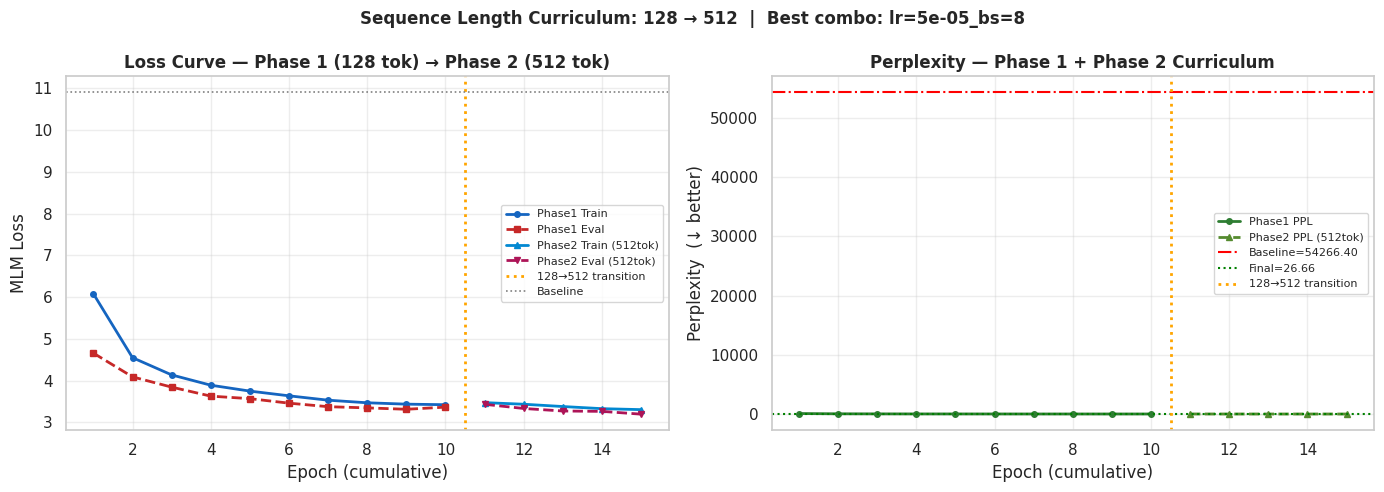

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_phase1_phase2_curriculum.png


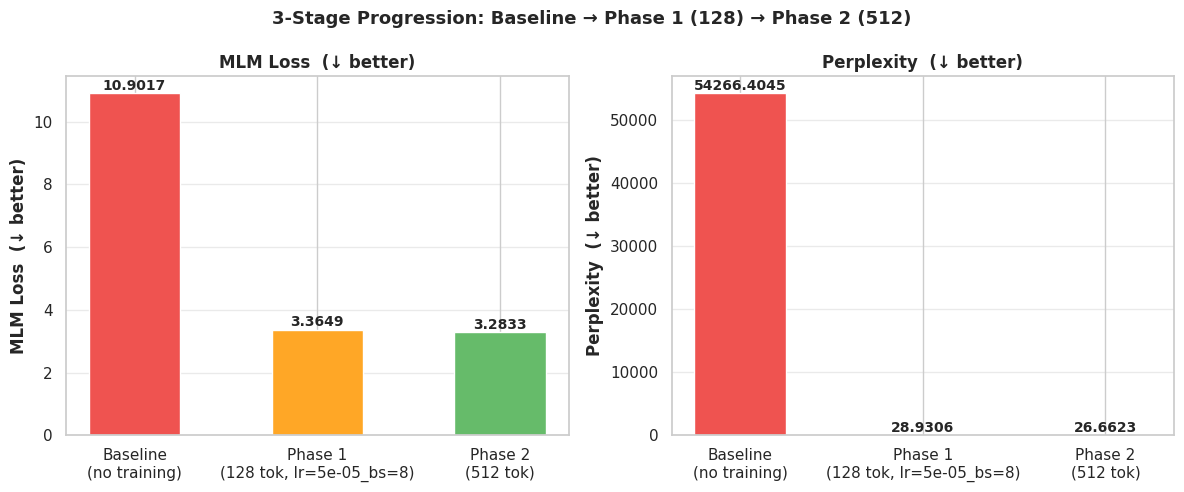

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_3stage_comparison.png


In [ ]:
# ── Evaluate final model ──────────────────────────────────────────
print('📏 Computing AFTER metrics (Phase 2 model, eval on 512 tokens)...')
best_model = AutoModelForMaskedLM.from_pretrained(
    PATHS['model_dir'],
    attn_implementation="eager" # Added to resolve a warning related to attention implementation.
).to(DEVICE)

AFTER_METRICS = compute_perplexity(
    best_model, eval_ds_512, collator_512, batch_size=32, desc='Post-DAPT'
)
print(f'\n   BEFORE — PPL : {BEFORE_METRICS["perplexity"]}')
print(f'   AFTER  — PPL : {AFTER_METRICS["perplexity"]}')

# Best Phase 1 perplexity (from best combo's last epoch)
PHASE1_METRICS = {
    'loss'      : GRID_RESULTS[BEST_COMBO_KEY]['final_eval_loss'],
    'perplexity': GRID_RESULTS[BEST_COMBO_KEY]['final_perplexity'],
}

loss_delta = AFTER_METRICS['loss']       - BEFORE_METRICS['loss']
ppl_delta  = AFTER_METRICS['perplexity'] - BEFORE_METRICS['perplexity']
loss_pct   = loss_delta / BEFORE_METRICS['loss']  * 100
ppl_pct    = ppl_delta  / BEFORE_METRICS['perplexity'] * 100

print(f'\n   Improvement (vs Baseline):'
      f' Loss {loss_pct:+.2f}% | PPL {ppl_pct:+.2f}%')

# PLOT F — Phase 1 best combo + Phase 2 stitched together
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p1_df = GRID_RESULTS[BEST_COMBO_KEY]['log_df']
p2_df = log_df_p2.copy()
p2_df['epoch'] = p2_df['epoch'] + p1_df['epoch'].max()   

# Loss
ax = axes[0]
ax.plot(p1_df['epoch'], p1_df['train_loss'], lw=2, color='#1565C0',
        marker='o', ms=4, label='Phase1 Train')
ax.plot(p1_df['epoch'], p1_df['eval_loss'],  lw=2, color='#C62828',
        ls='--', marker='s', ms=4, label='Phase1 Eval')
ax.plot(p2_df['epoch'], p2_df['train_loss'], lw=2, color='#0288D1',
        marker='^', ms=5, label='Phase2 Train (512tok)')
ax.plot(p2_df['epoch'], p2_df['eval_loss'],  lw=2, color='#AD1457',
        ls='--', marker='v', ms=5, label='Phase2 Eval (512tok)')
ax.axvline(p1_df['epoch'].max() + 0.5, color='orange', lw=2, ls=':',
           label='128→512 transition')
ax.axhline(BEFORE_METRICS['loss'], color='gray', ls=':', lw=1.2,
           label='Baseline')
ax.set_title('Loss Curve — Phase 1 (128 tok) → Phase 2 (512 tok)',
             fontweight='bold')
ax.set_xlabel('Epoch (cumulative)'); ax.set_ylabel('MLM Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.35)

# Perplexity
ax = axes[1]
ax.plot(p1_df['epoch'], p1_df['perplexity'], lw=2, color='#2E7D32',
        marker='o', ms=4, label='Phase1 PPL')
ax.plot(p2_df['epoch'], p2_df['perplexity'], lw=2, color='#558B2F',
        ls='--', marker='^', ms=5, label='Phase2 PPL (512tok)')
ax.axhline(BEFORE_METRICS['perplexity'], color='red', ls='-.', lw=1.5,
           label=f'Baseline={BEFORE_METRICS["perplexity"]:.2f}')
ax.axhline(AFTER_METRICS['perplexity'], color='green', ls=':', lw=1.5,
           label=f'Final={AFTER_METRICS["perplexity"]:.2f}')
ax.axvline(p1_df['epoch'].max() + 0.5, color='orange', lw=2, ls=':',
           label='128→512 transition')
ax.fill_between(p2_df['epoch'], p2_df['perplexity'],
                alpha=0.1, color='#558B2F')
ax.set_title('Perplexity — Phase 1 + Phase 2 Curriculum',
             fontweight='bold')
ax.set_xlabel('Epoch (cumulative)'); ax.set_ylabel('Perplexity  (↓ better)')
ax.legend(fontsize=8); ax.grid(alpha=0.35)

plt.suptitle(
    f'Sequence Length Curriculum: 128 → 512  |  Best combo: {BEST_COMBO_KEY}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapt_phase1_phase2_curriculum.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

# PLOT G — 3-stage comparison: Baseline → Phase1 → Phase2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stages      = ['Baseline\n(no training)', f'Phase 1\n(128 tok, {BEST_COMBO_KEY})', f'Phase 2\n(512 tok)']
loss_vals   = [BEFORE_METRICS['loss'],       PHASE1_METRICS['loss'],       AFTER_METRICS['loss']]
ppl_vals    = [BEFORE_METRICS['perplexity'], PHASE1_METRICS['perplexity'], AFTER_METRICS['perplexity']]
stage_colors= ['#EF5350', '#FFA726', '#66BB6A']

for ax, vals, ylabel in [
    (axes[0], loss_vals, 'MLM Loss  (↓ better)'),
    (axes[1], ppl_vals,  'Perplexity  (↓ better)'),
]:
    bars = ax.bar(stages, vals, color=stage_colors, edgecolor='white', width=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(ylabel, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('3-Stage Progression: Baseline → Phase 1 (128) → Phase 2 (512)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapt_3stage_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {save_path}')

Dropout in model: hidden=0.2, attn=0.2


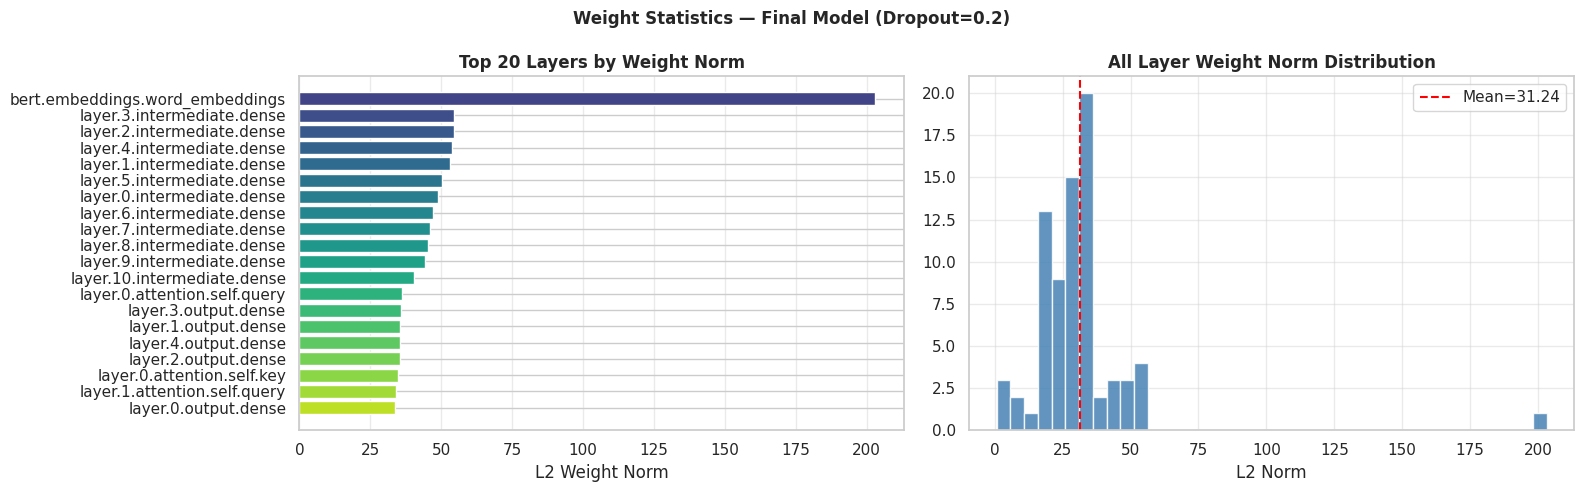

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_weight_norms.png


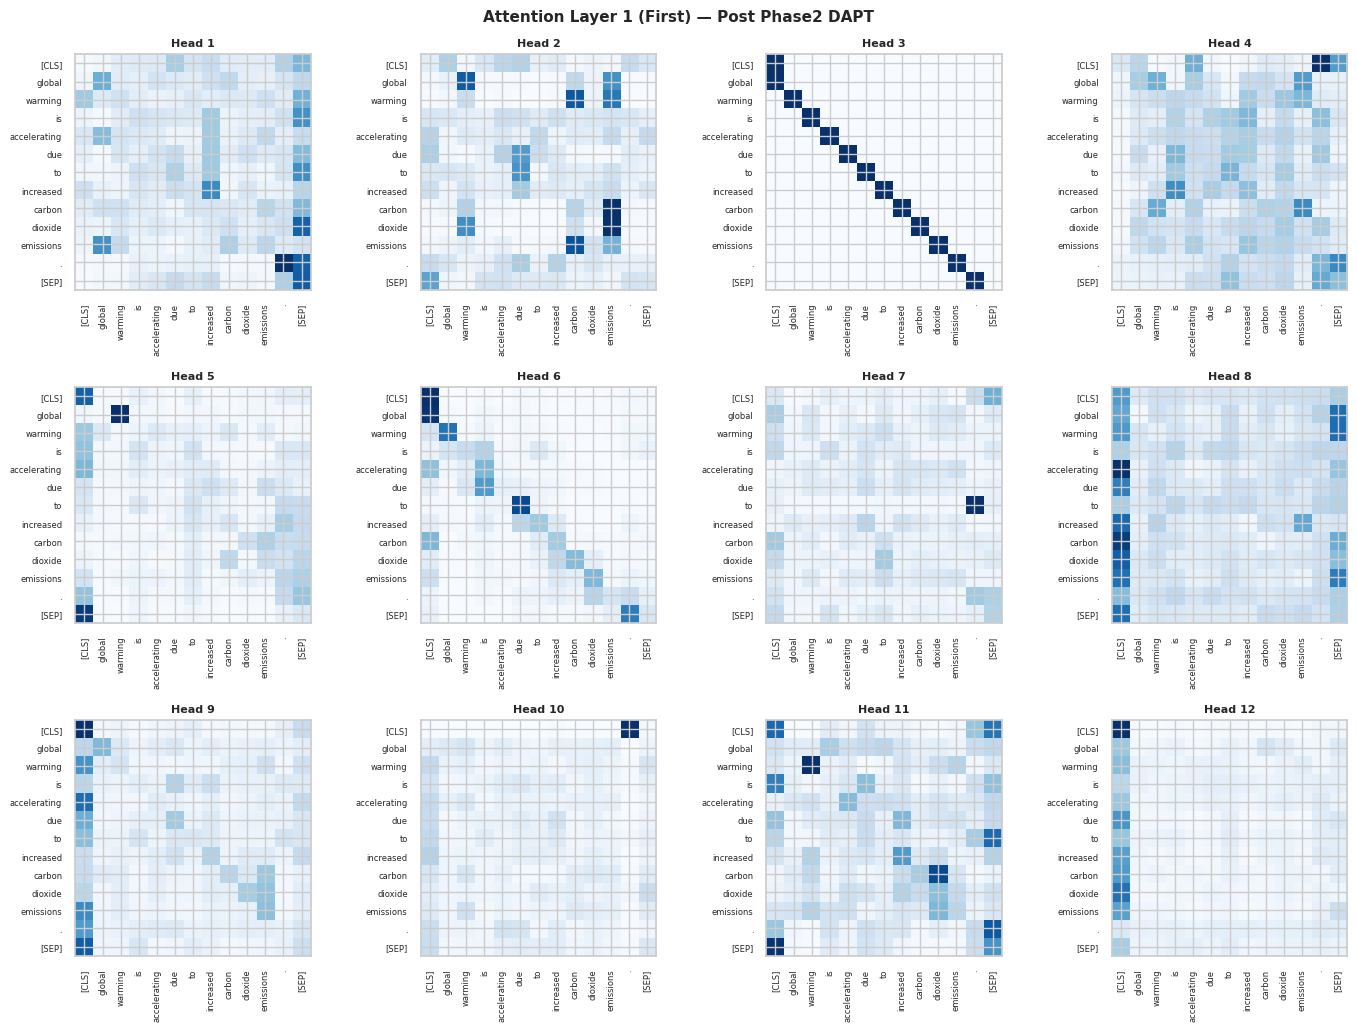

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_attention_layer1.png


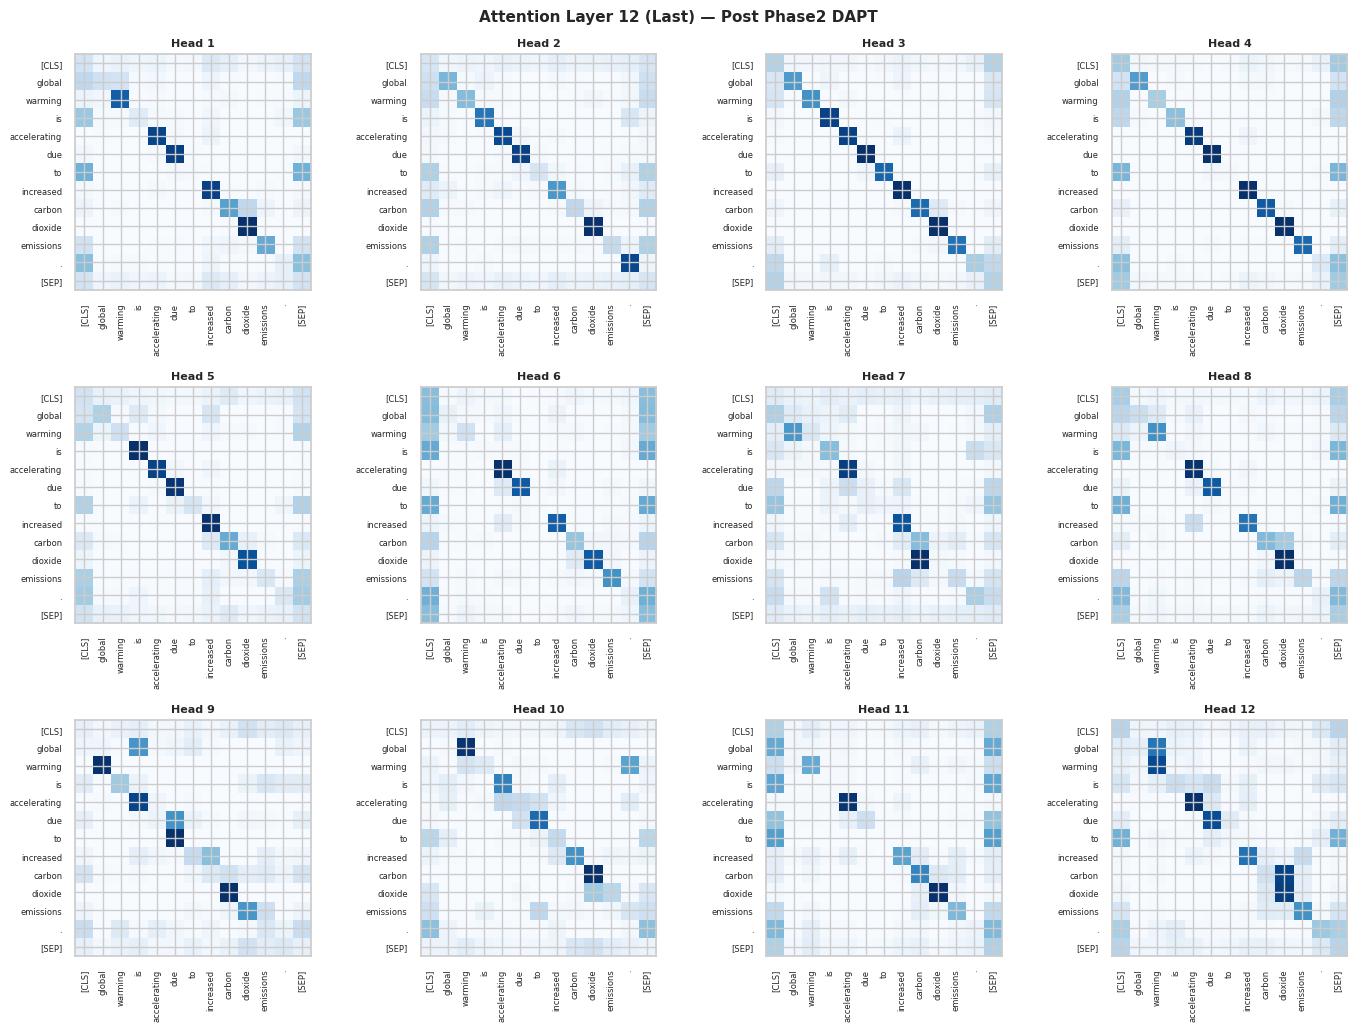

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_attention_layer12.png


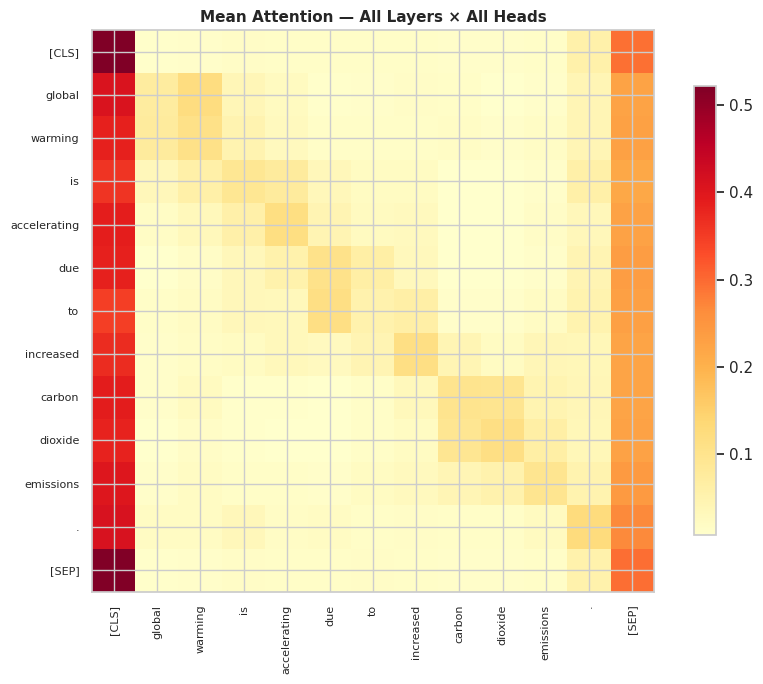

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_mean_attention.png


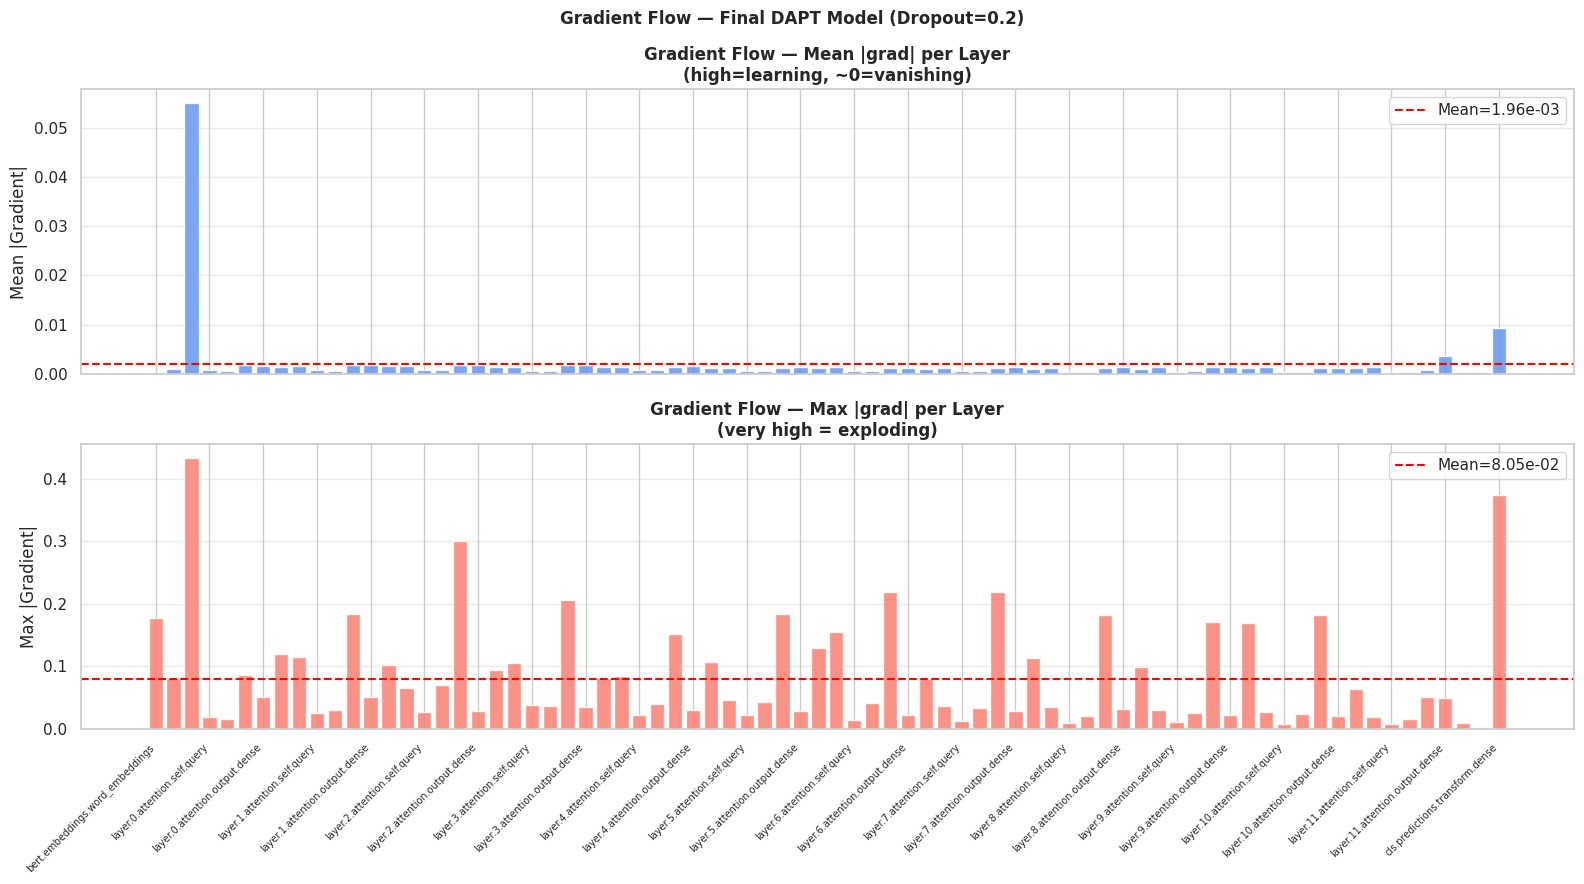

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_gradient_flow.png

Gradient Health: dead=0/76 | mean=1.9557e-03 | max=4.3338e-01
✅  Gradients healthy


Some weights of BertForMaskedLM were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


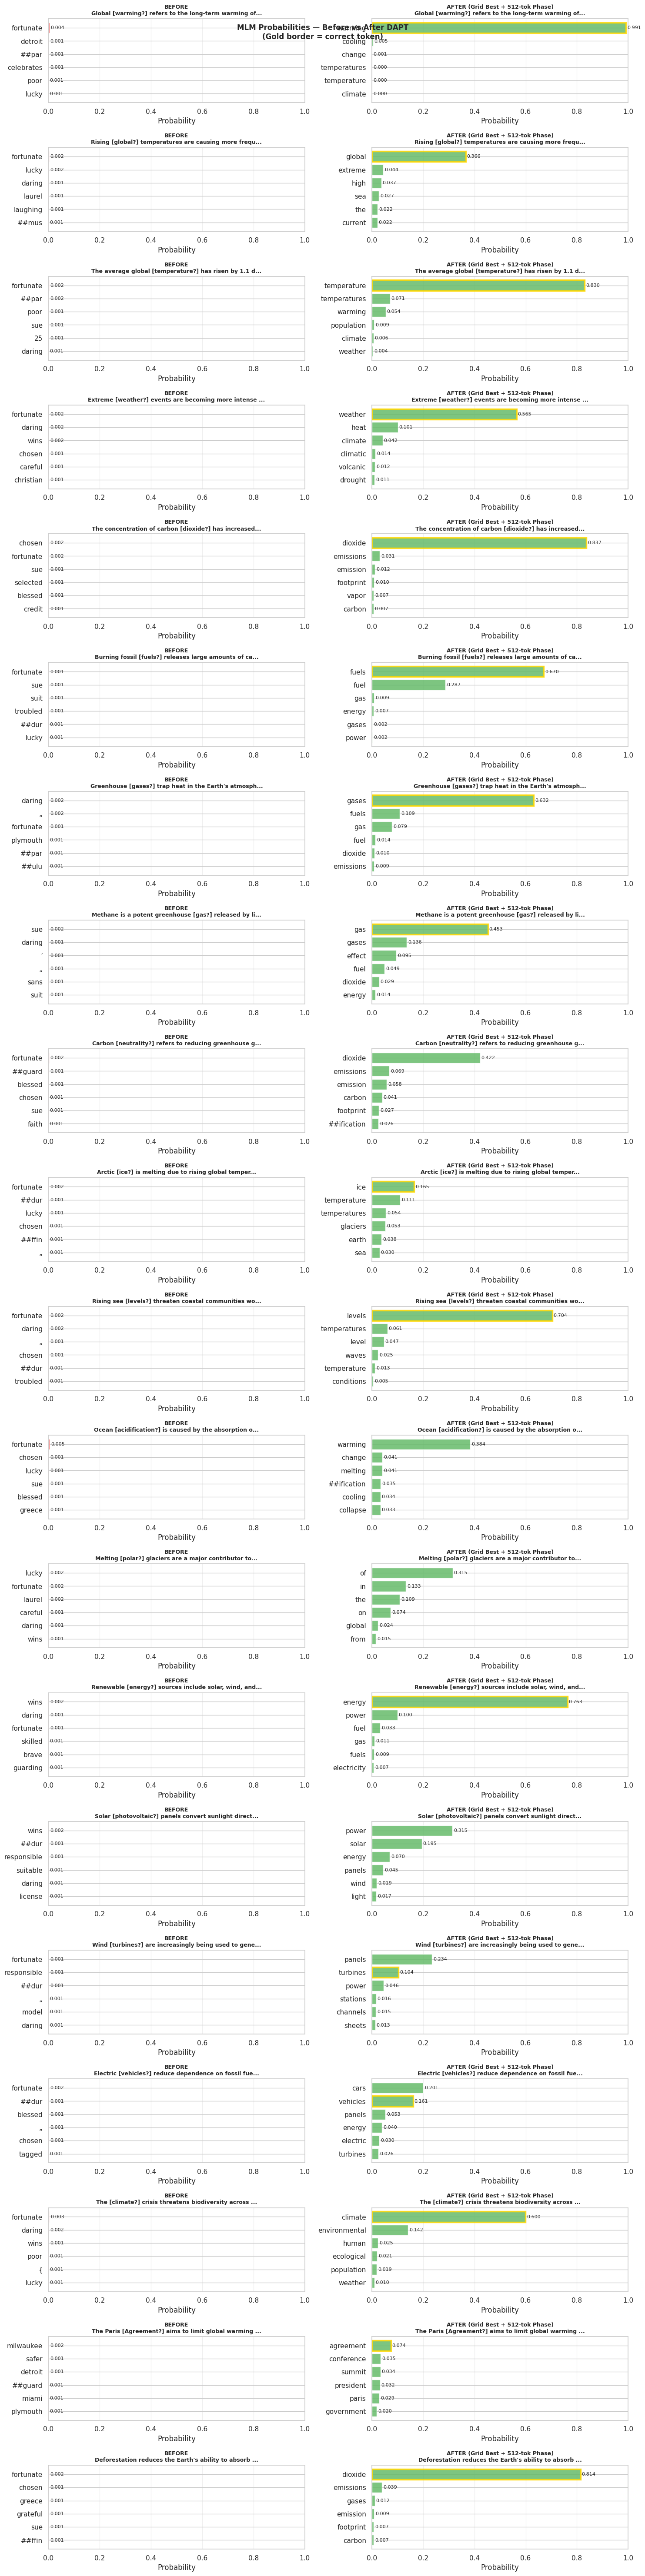

✅ Saved → /content/drive/MyDrive/Rajdeep_Document/plots/dapt_mlm_probabilities.png

Sentence                                         Before     After     Delta
---------------------------------------------------------------------------
✅  Global [warming] refers to the long-term wa    0.0000    0.9909   +0.9909
✅  Rising [global] temperatures are causing mo    0.0000    0.3662   +0.3662
✅  The average global [temperature] has risen     0.0000    0.8304   +0.8304
✅  Extreme [weather] events are becoming more     0.0000    0.5648   +0.5648
✅  The concentration of carbon [dioxide] has i    0.0000    0.8371   +0.8371
✅  Burning fossil [fuels] releases large amoun    0.0000    0.6702   +0.6702
✅  Greenhouse [gases] trap heat in the Earth's    0.0000    0.6318   +0.6318
✅  Methane is a potent greenhouse [gas] releas    0.0000    0.4528   +0.4528
⚠️   Carbon [neutrality] refers to reducing gree    0.0000    0.0000   +0.0000
✅  Arctic [ice] is melting due to rising globa    0.0000    0.1654   

In [ ]:
# INTERNAL VIZ 1 — Weight Norms
best_model.eval()
print(f'Dropout in model: hidden={best_model.config.hidden_dropout_prob}, '
      f'attn={best_model.config.attention_probs_dropout_prob}')

layer_names, weight_norms = [], []
for name, param in best_model.named_parameters():
    if 'weight' in name and param.dim() >= 2:
        layer_names.append(name.replace('bert.encoder.','').replace('.weight',''))
        weight_norms.append(param.data.norm(2).item())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_n   = 20
indices = np.argsort(weight_norms)[-top_n:][::-1]
axes[0].barh(
    [layer_names[i][:48] for i in indices],
    [weight_norms[i] for i in indices],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
)
axes[0].set_xlabel('L2 Weight Norm'); axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} Layers by Weight Norm', fontweight='bold')
axes[0].grid(axis='x', alpha=0.4)

axes[1].hist(weight_norms, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(weight_norms), color='red', ls='--',
                label=f'Mean={np.mean(weight_norms):.2f}')
axes[1].set_title('All Layer Weight Norm Distribution', fontweight='bold')
axes[1].set_xlabel('L2 Norm'); axes[1].legend(); axes[1].grid(alpha=0.4)
plt.suptitle('Weight Statistics — Final Model (Dropout=0.2)', fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapt_weight_norms.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show(); print(f'✅ Saved → {save_path}')

# INTERNAL VIZ 2 — Attention Heatmaps
import math as _math

PROBE_TEXT = "Global warming is accelerating due to increased carbon dioxide emissions."
inputs = tokenizer(PROBE_TEXT, return_tensors='pt',
                   truncation=True, max_length=128).to(DEVICE)
with torch.no_grad():
    outputs = best_model(**inputs, output_attentions=True)

attentions = outputs.attentions
tokens     = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
n_layers   = len(attentions)

for layer_idx in [0, n_layers-1]:
    attn = attentions[layer_idx][0].cpu().numpy()
    n_h  = attn.shape[0]
    cols = 4; rows = _math.ceil(n_h / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.5))
    axes = axes.flatten()
    for h in range(n_h):
        axes[h].imshow(attn[h], cmap='Blues', vmin=0)
        axes[h].set_xticks(range(len(tokens))); axes[h].set_xticklabels(tokens, rotation=90, fontsize=6)
        axes[h].set_yticks(range(len(tokens))); axes[h].set_yticklabels(tokens, fontsize=6)
        axes[h].set_title(f'Head {h+1}', fontsize=8, fontweight='bold')
    for h in range(n_h, len(axes)): axes[h].axis('off')
    lbl = 'First' if layer_idx == 0 else 'Last'
    plt.suptitle(f'Attention Layer {layer_idx+1} ({lbl}) — Post Phase2 DAPT',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    save_path = f"{PATHS['plots_dir']}/dapt_attention_layer{layer_idx+1}.png"
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show(); print(f'✅ Saved → {save_path}')

# Mean attention
all_attn  = np.stack([a[0].mean(0).cpu().numpy() for a in attentions])
mean_attn = all_attn.mean(0)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(mean_attn, cmap='YlOrRd')
ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=8)
ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Mean Attention — All Layers × All Heads', fontsize=11, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapt_mean_attention.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show(); print(f'✅ Saved → {save_path}')

# INTERNAL VIZ 3 — Gradient Flow
best_model.train()
best_model.zero_grad()
sample_batch = collator_128([eval_ds_128[i] for i in range(16)])   
sample_batch = {k: v.to(DEVICE) for k, v in sample_batch.items()}
best_model(**sample_batch).loss.backward()

grad_layers, grad_means, grad_maxes = [], [], []
for name, param in best_model.named_parameters():
    if param.grad is not None and 'weight' in name and param.dim() >= 2:
        g = param.grad.abs()
        grad_layers.append(name.replace('bert.encoder.','').replace('.weight',''))
        grad_means.append(g.mean().item())
        grad_maxes.append(g.max().item())

best_model.zero_grad(); best_model.eval()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
x = np.arange(len(grad_layers))
axes[0].bar(x, grad_means, color='cornflowerblue', alpha=0.85)
axes[0].axhline(np.mean(grad_means), color='red', ls='--',
                label=f'Mean={np.mean(grad_means):.2e}')
axes[0].set_ylabel('Mean |Gradient|'); axes[0].legend()
axes[0].set_title('Gradient Flow — Mean |grad| per Layer\n(high=learning, ~0=vanishing)',
                  fontweight='bold'); axes[0].grid(axis='y', alpha=0.4)

axes[1].bar(x, grad_maxes, color='salmon', alpha=0.85)
axes[1].axhline(np.mean(grad_maxes), color='red', ls='--',
                label=f'Mean={np.mean(grad_maxes):.2e}')
axes[1].set_ylabel('Max |Gradient|'); axes[1].legend()
axes[1].set_title('Gradient Flow — Max |grad| per Layer\n(very high = exploding)',
                  fontweight='bold'); axes[1].grid(axis='y', alpha=0.4)

step = max(1, len(grad_layers) // 20)
axes[1].set_xticks(x[::step])
axes[1].set_xticklabels(grad_layers[::step], rotation=45, ha='right', fontsize=7)
plt.suptitle('Gradient Flow — Final DAPT Model (Dropout=0.2)', fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapt_gradient_flow.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show(); print(f'✅ Saved → {save_path}')

dead = sum(1 for g in grad_means if g < 1e-7)
print(f'\nGradient Health: dead={dead}/{len(grad_means)} | '
      f'mean={np.mean(grad_means):.4e} | max={np.max(grad_maxes):.4e}')
if np.max(grad_maxes) > 1.0:
    print('⚠️  Large gradients — add max_grad_norm=1.0 to TrainingArguments')
else:
    print('✅  Gradients healthy')

# INTERNAL VIZ 4 — MLM Token Probabilities (Before vs After)
from transformers import pipeline as hf_pipeline

MASK = tokenizer.mask_token
fill_before = hf_pipeline('fill-mask', model=CFG['base_model'],
                           device=0 if torch.cuda.is_available() else -1)
fill_after  = hf_pipeline('fill-mask', model=PATHS['model_dir'],
                           device=0 if torch.cuda.is_available() else -1)

PROBES = [
    # ── Temperature & Warming ─────────────────────────────────────
    (f"Global {MASK} refers to the long-term warming of the planet.",           'warming'),
    (f"Rising {MASK} temperatures are causing more frequent heatwaves.",        'global'),
    (f"The average global {MASK} has risen by 1.1 degrees Celsius since 1850.", 'temperature'),
    (f"Extreme {MASK} events are becoming more intense due to climate change.",  'weather'),

    # ── Carbon & Emissions ────────────────────────────────────────
    (f"The concentration of carbon {MASK} has increased rapidly.",              'dioxide'),
    (f"Burning fossil {MASK} releases large amounts of carbon dioxide.",        'fuels'),
    (f"Greenhouse {MASK} trap heat in the Earth's atmosphere.",                 'gases'),
    (f"Methane is a potent greenhouse {MASK} released by livestock.",           'gas'),
    (f"Carbon {MASK} refers to reducing greenhouse gas emissions to zero.",     'neutrality'),

    # ── Ice, Sea & Ocean ─────────────────────────────────────────
    (f"Arctic {MASK} is melting due to rising global temperatures.",            'ice'),
    (f"Rising sea {MASK} threaten coastal communities worldwide.",              'levels'),
    (f"Ocean {MASK} is caused by the absorption of excess carbon dioxide.",     'acidification'),
    (f"Melting {MASK} glaciers are a major contributor to sea level rise.",     'polar'),

    # ── Energy & Solutions ────────────────────────────────────────
    (f"Renewable {MASK} sources include solar, wind, and hydro power.",        'energy'),
    (f"Solar {MASK} panels convert sunlight directly into electricity.",        'photovoltaic'),
    (f"Wind {MASK} are increasingly being used to generate clean electricity.", 'turbines'),
    (f"Electric {MASK} reduce dependence on fossil fuels for transportation.",  'vehicles'),

    # ── Policy & Impact ───────────────────────────────────────────
    (f"The {MASK} crisis threatens biodiversity across the planet.",            'climate'),
    (f"The Paris {MASK} aims to limit global warming to 1.5 degrees Celsius.", 'Agreement'),
    (f"Deforestation reduces the Earth's ability to absorb carbon {MASK}.",    'dioxide'),
]

fig, axes = plt.subplots(len(PROBES), 2, figsize=(15, len(PROBES) * 3.0))

def plot_fill_bar(ax, results, title, color, expected):
    toks = [r['token_str'].strip() for r in results]
    scs  = [r['score'] for r in results]
    bars = ax.barh(toks[::-1], scs[::-1], color=color, alpha=0.85, edgecolor='white')
    for bar, sc in zip(bars, scs[::-1]):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{sc:.3f}', va='center', fontsize=8)
    for i, t in enumerate(toks[::-1]):
        if t.lower() == expected.lower():
            bars[i].set_edgecolor('gold'); bars[i].set_linewidth(2.5)
    ax.set_xlim(0, 1.0); ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Probability'); ax.grid(axis='x', alpha=0.3)

for row, (sent, expected) in enumerate(PROBES):
    rb = fill_before(sent, top_k=6); ra = fill_after(sent, top_k=6)
    short = sent.replace(MASK, f'[{expected}?]')[:52] + '...'
    plot_fill_bar(axes[row][0], rb, f'BEFORE\n{short}', '#EF5350', expected)
    plot_fill_bar(axes[row][1], ra, f'AFTER (Grid Best + 512-tok Phase)\n{short}', '#66BB6A', expected)

plt.suptitle('MLM Probabilities — Before vs After DAPT\n(Gold border = correct token)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f"{PATHS['plots_dir']}/dapt_mlm_probabilities.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show(); print(f'✅ Saved → {save_path}')

print(f'\n{"Sentence":<45}  {"Before":>8}  {"After":>8}  {"Delta":>8}')
print('-'*75)
for sent, expected in PROBES:
    rb = fill_before(sent, top_k=50); ra = fill_after(sent, top_k=50)
    def gp(res, tok):
        for r in res:
            if r['token_str'].strip().lower() == tok.lower(): return r['score']
        return 0.0
    pb = gp(rb, expected); pa = gp(ra, expected)
    lbl  = sent.replace(MASK, f'[{expected}]')[:43]
    print(f'{"✅" if pa>pb else "⚠️ "}  {lbl:43s}  {pb:8.4f}  {pa:8.4f}  {pa-pb:+8.4f}')

In [21]:
# ── Save evaluation results ───────────────────────────────────────
eval_results = {
    'before_dapt'  : BEFORE_METRICS,
    'phase1_best'  : PHASE1_METRICS,
    'after_dapt'   : AFTER_METRICS,
    'improvement'  : {
        'loss_pct_change': round(loss_pct, 4),
        'ppl_pct_change' : round(ppl_pct,  4),
    },
    'grid_search'  : {
        'best_combo': BEST_COMBO_KEY,
        'best_lr'   : BEST_COMBO_CFG['lr'],
        'best_bs'   : BEST_COMBO_CFG['batch_size'],
        'all_combos': {k: {
            'final_perplexity': v['final_perplexity'],
            'best_perplexity' : v['best_perplexity'],
            'train_time_min'  : v['train_time_min'],
        } for k, v in GRID_RESULTS.items()},
    },
    'training_config' : {k: v for k, v in CFG.items() if isinstance(v, (str,int,float,bool))},
    'timestamp'       : datetime.now().isoformat(),
}
with open(PATHS['eval_json'], 'w') as f:
    json.dump(eval_results, f, indent=2)

report = f"""
╔═══════════════════════════════════════════════════════════════╗
║       DAPT FINAL REPORT — Grid Search + Curriculum           ║
╚═══════════════════════════════════════════════════════════════╝
Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

TRAINING STRATEGY
  Base Model       : {CFG['base_model']}
  Task             : Masked Language Modeling (MLM) — dynamic masking
  Grid LR          : {GRID_LR}
  Grid Batch Size  : {GRID_BATCH}
  Total combos     : {len(GRID_RESULTS)}
  Phase 1 seq_len  : {CFG['seq_len_phase1']} tokens  ({CFG['grid_epochs']} epochs)
  Phase 2 seq_len  : {CFG['seq_len_phase2']} tokens  ({CFG['phase2_epochs']} epochs)
  Dropout          : {CFG['dropout']}

GRID SEARCH WINNER
  Best combo       : {BEST_COMBO_KEY}
  Phase 1 PPL      : {PHASE1_METRICS['perplexity']:.4f}

METRICS
  Stage          Loss       Perplexity
  Baseline     : {BEFORE_METRICS['loss']:.6f}   {BEFORE_METRICS['perplexity']:.4f}
  Post Phase 1 : {PHASE1_METRICS['loss']:.6f}   {PHASE1_METRICS['perplexity']:.4f}
  Post Phase 2 : {AFTER_METRICS['loss']:.6f}   {AFTER_METRICS['perplexity']:.4f}
  Improvement  : {loss_pct:+.2f}% loss  |  {ppl_pct:+.2f}% perplexity

PLOTS SAVED
  grid_loss_panel.png          — 3x3 loss curves per combo
  grid_all_perplexity.png      — all 9 combos on one chart
  grid_heatmap.png             — lr vs batch_size heatmap
  grid_ranked_bar.png          — combos ranked by perplexity
  grid_sensitivity.png         — LR & batch size sensitivity
  dapt_phase1_phase2_curriculum.png
  dapt_3stage_comparison.png
  dapt_weight_norms.png
  dapt_attention_layer1.png
  dapt_attention_layer12.png
  dapt_mean_attention.png
  dapt_gradient_flow.png
  dapt_mlm_probabilities.png

VERDICT
  {"DAPT SUCCESSFUL" if AFTER_METRICS['perplexity'] < BEFORE_METRICS['perplexity'] else "WARNING: perplexity did not improve"}
"""

with open(PATHS['report_txt'], 'w') as f:
    f.write(report)
print(report)
print(f'✅ Report → {PATHS["report_txt"]}')
print(f'✅ Eval JSON → {PATHS["eval_json"]}')


╔═══════════════════════════════════════════════════════════════╗
║       DAPT FINAL REPORT — Grid Search + Curriculum           ║
╚═══════════════════════════════════════════════════════════════╝
Generated : 2026-05-14 12:58:04

TRAINING STRATEGY
  Base Model       : microsoft/MiniLM-L12-H384-uncased
  Task             : Masked Language Modeling (MLM) — dynamic masking
  Grid LR          : [1e-05, 3e-05, 5e-05]
  Grid Batch Size  : [8, 16, 32]
  Total combos     : 9
  Phase 1 seq_len  : 128 tokens  (10 epochs)
  Phase 2 seq_len  : 512 tokens  (5 epochs)
  Dropout          : 0.2

GRID SEARCH WINNER
  Best combo       : lr=5e-05_bs=8
  Phase 1 PPL      : 28.9306

METRICS
  Stage          Loss       Perplexity
  Baseline     : 10.901700   54266.4045
  Post Phase 1 : 3.364898   28.9306
  Post Phase 2 : 3.283300   26.6623
  Improvement  : -69.88% loss  |  -99.95% perplexity

PLOTS SAVED
  grid_loss_panel.png          — 3x3 loss curves per combo
  grid_all_perplexity.png      — all 9 combo